In [28]:
# Import and load data
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from utils import RAW_DATA_PATH, TARGET_COL, FIGURES_DIR, DROP_COLS
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv(RAW_DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [29]:
# Data Exploration
print("=== INFO ===")
df.info()

print("\n=== MISSING VALUES ===")
print(df.isnull().sum().sum(), "total missing values")

print("\n=== DUPLICATE ROWS ===")
print(df.duplicated().sum())

print("\n=== CONSTANT FEATURES (zero variance) ===")
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"{col} -> only value: {df[col].unique()}")

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel   

In [30]:
#  Drop Constant/Useless Columns
df = df.drop(columns=DROP_COLS, errors="ignore")
print(f"Shape after dropping constants: {df.shape}")

Shape after dropping constants: (1470, 31)


C:\Users\User\AppData\Local\Temp\ipykernel_19336\1801297606.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=TARGET_COL, ax=axes[0], palette=["#2ecc71", "#e74c3c"])


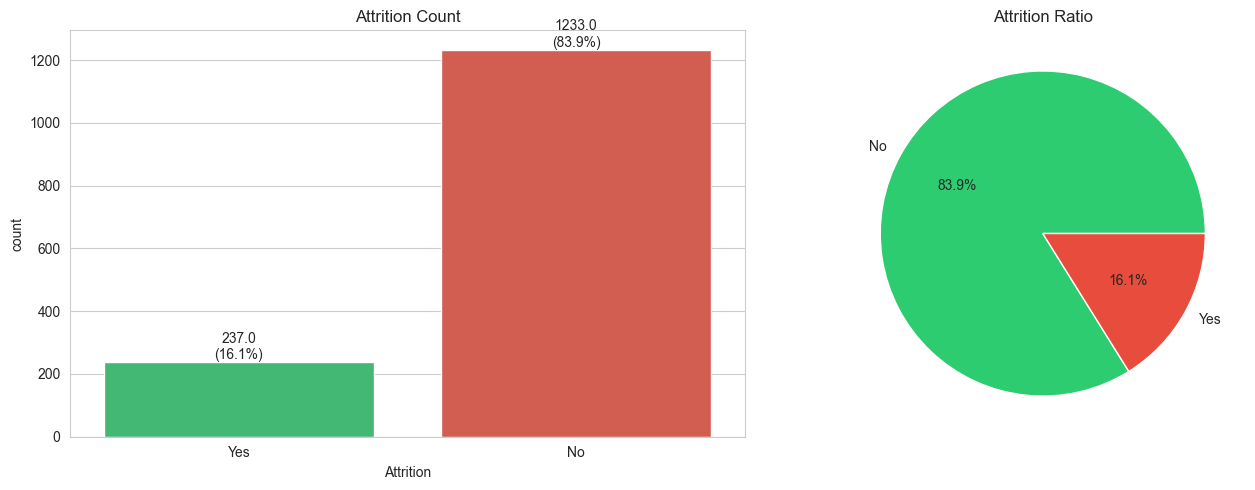

Imbalance Ratio (No:Yes) = 5.20 : 1


In [31]:
# Target Variable Analysis (Phase 3)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x=TARGET_COL, ax=axes[0], palette=["#2ecc71", "#e74c3c"])
axes[0].set_title("Attrition Count")
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()}\n({100*p.get_height()/len(df):.1f}%)',
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom')

# Pie chart
df[TARGET_COL].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1],
                                          colors=["#2ecc71", "#e74c3c"])
axes[1].set_title("Attrition Ratio")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/target_distribution.png", dpi=150)
plt.show()

# Imbalance ratio
counts = df[TARGET_COL].value_counts()
ratio = counts["No"] / counts["Yes"]
print(f"Imbalance Ratio (No:Yes) = {ratio:.2f} : 1")

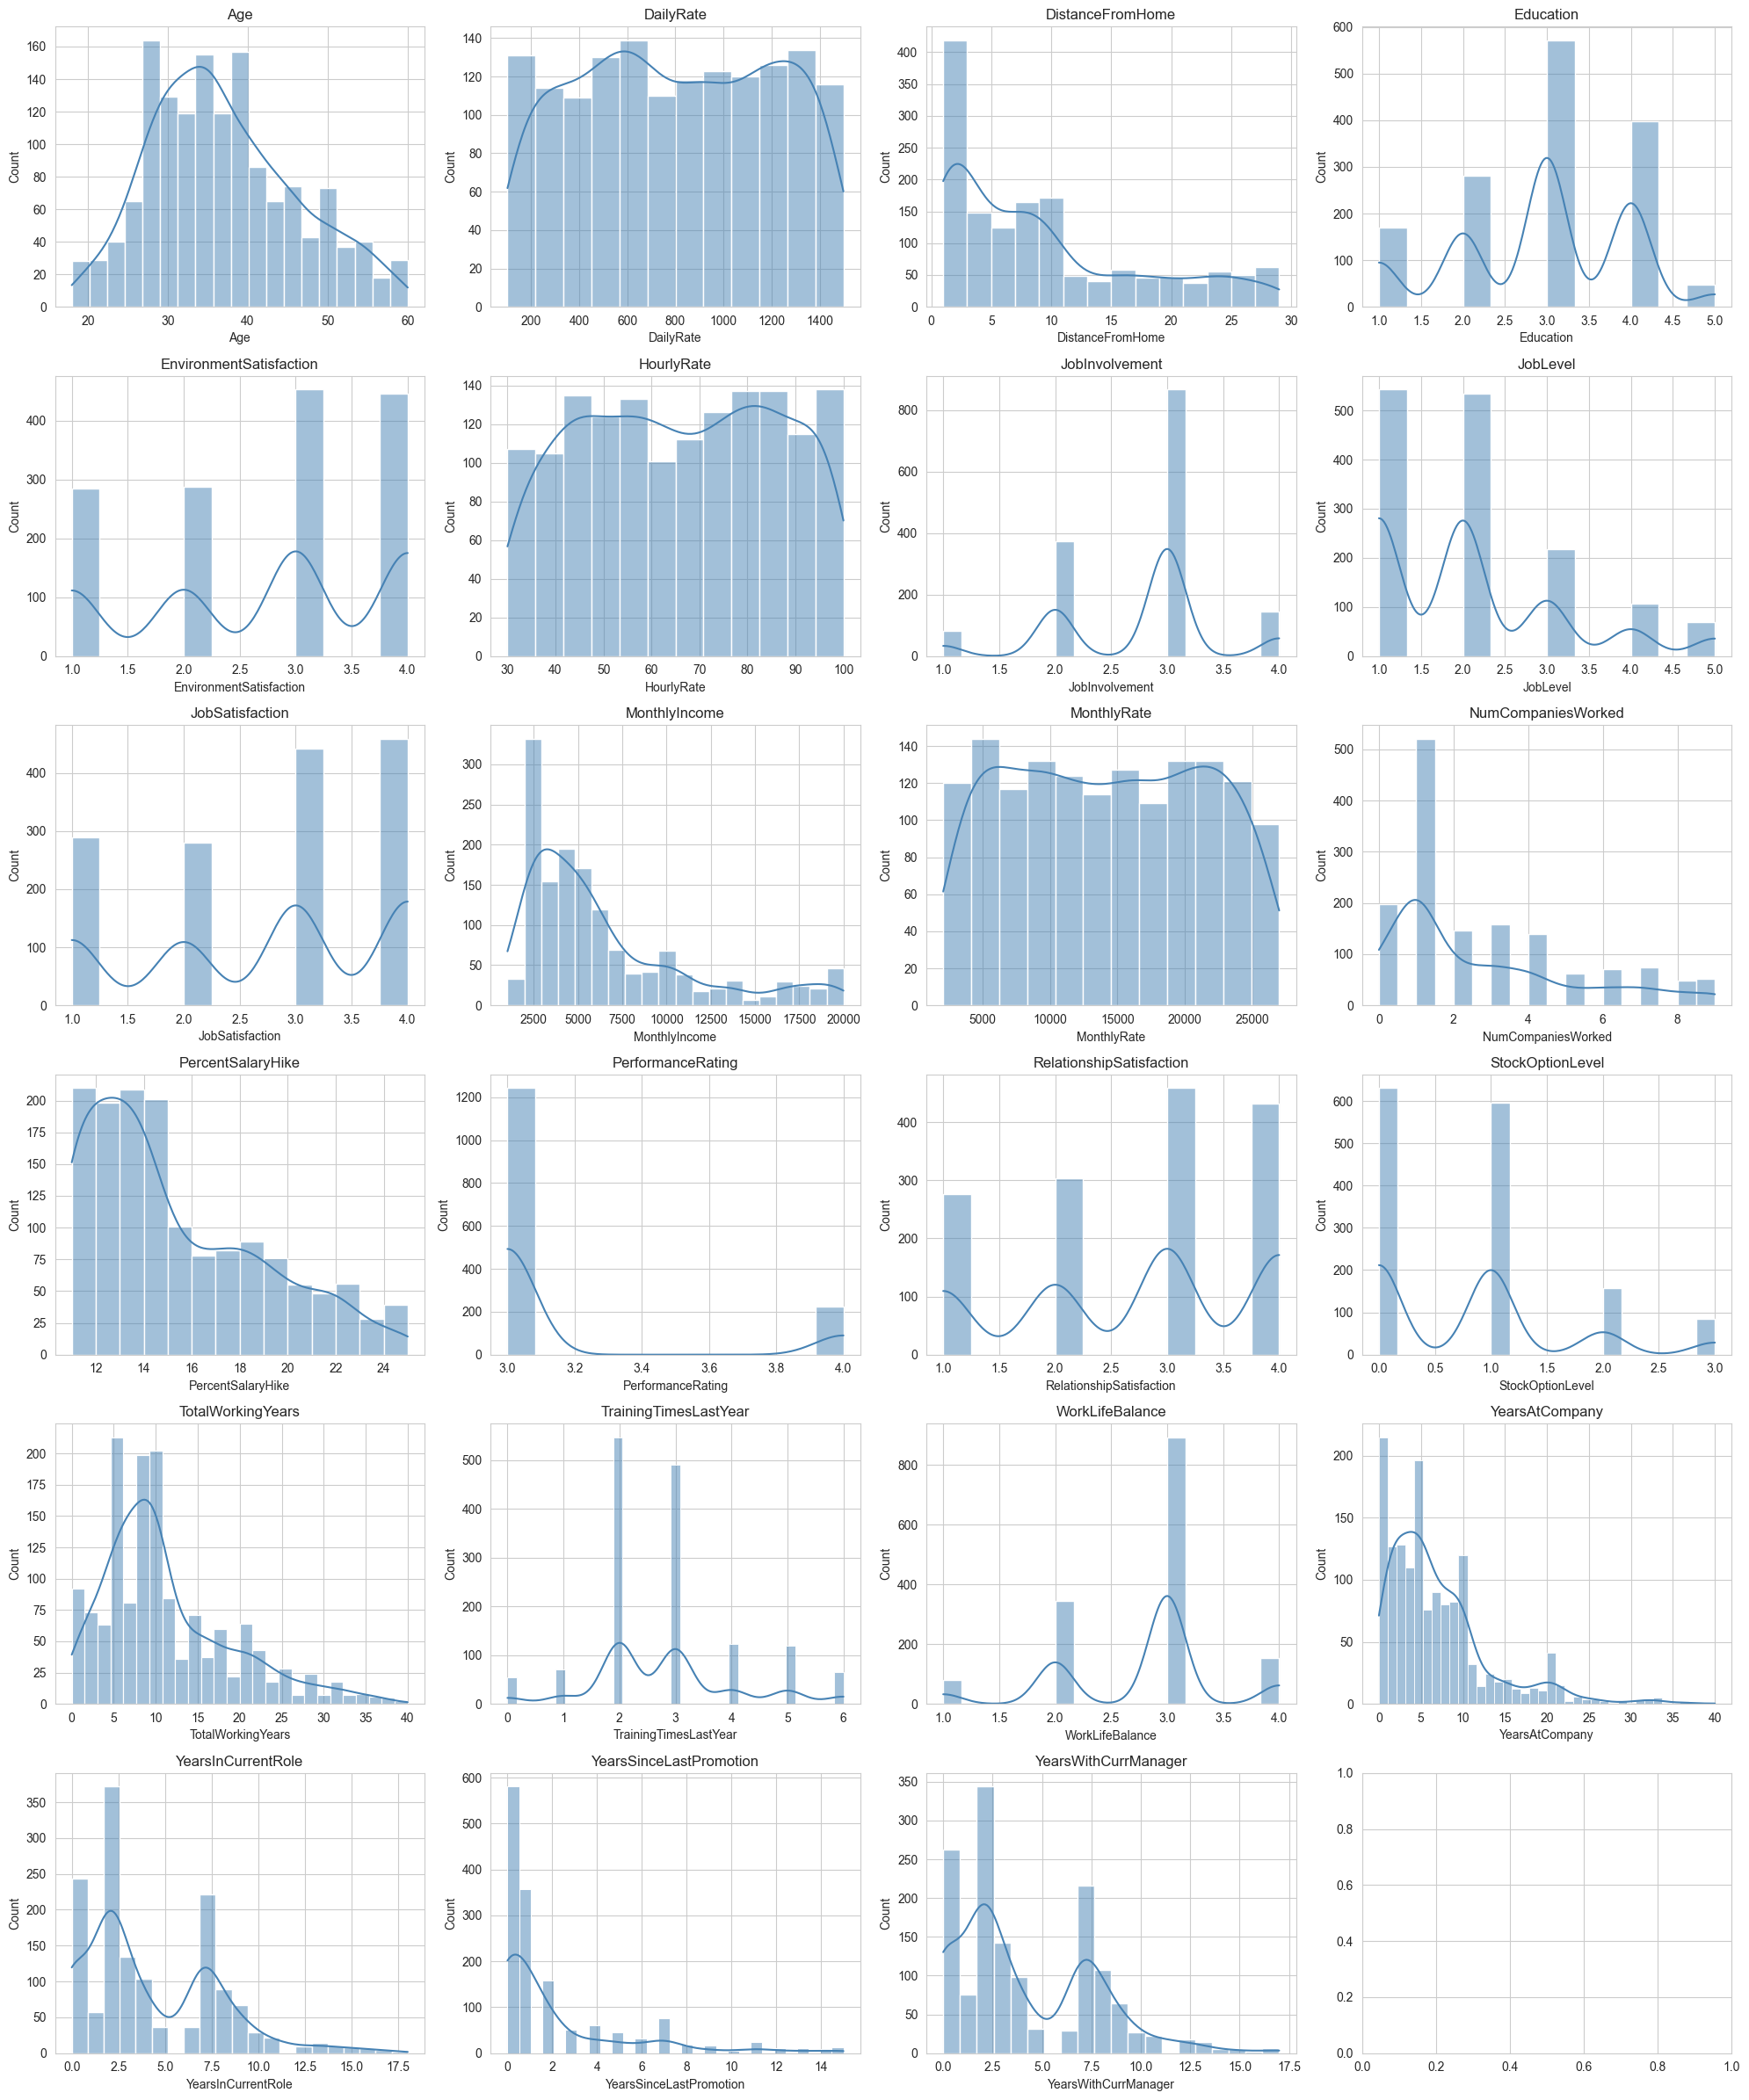

In [32]:
# Univariate: Numerical Features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# fig, axes = plt.subplots(5, 4, figsize=(20, 20))
fig, axes = plt.subplots(6, 4, figsize=(20, 24))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/numerical_distributions.png", dpi=150)
plt.show()

In [33]:
print(len(num_cols))
print(num_cols)

23
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


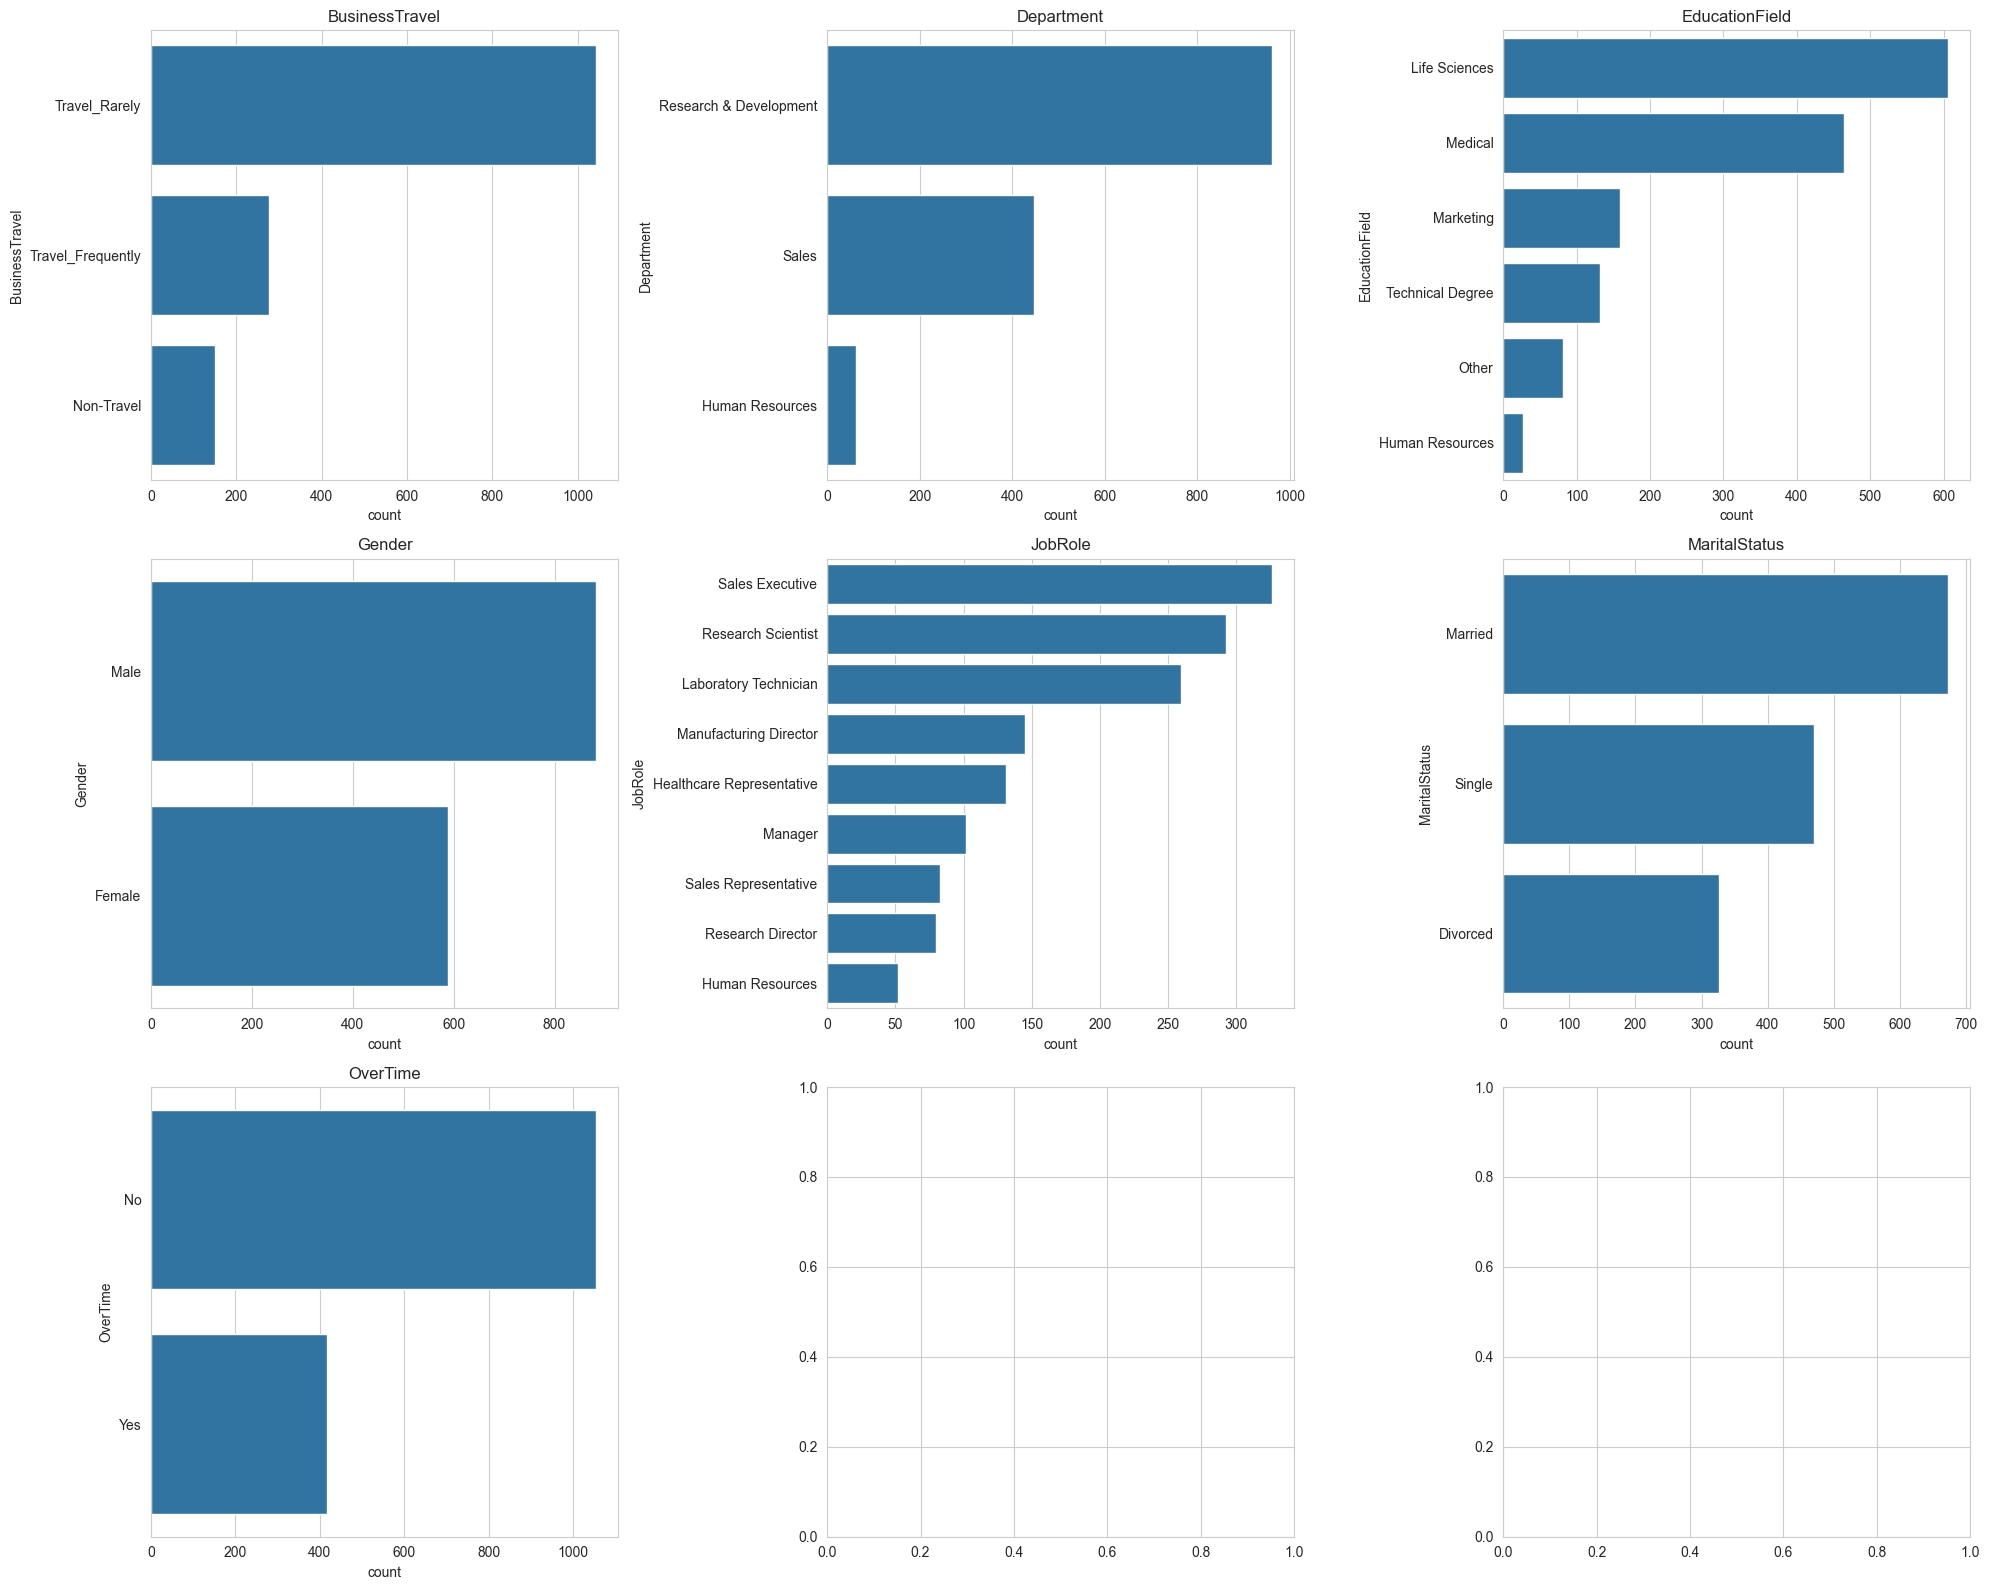

In [34]:
# Univariate: Categorical Features
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols.remove(TARGET_COL)

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, y=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/categorical_distributions.png", dpi=150)
plt.show()

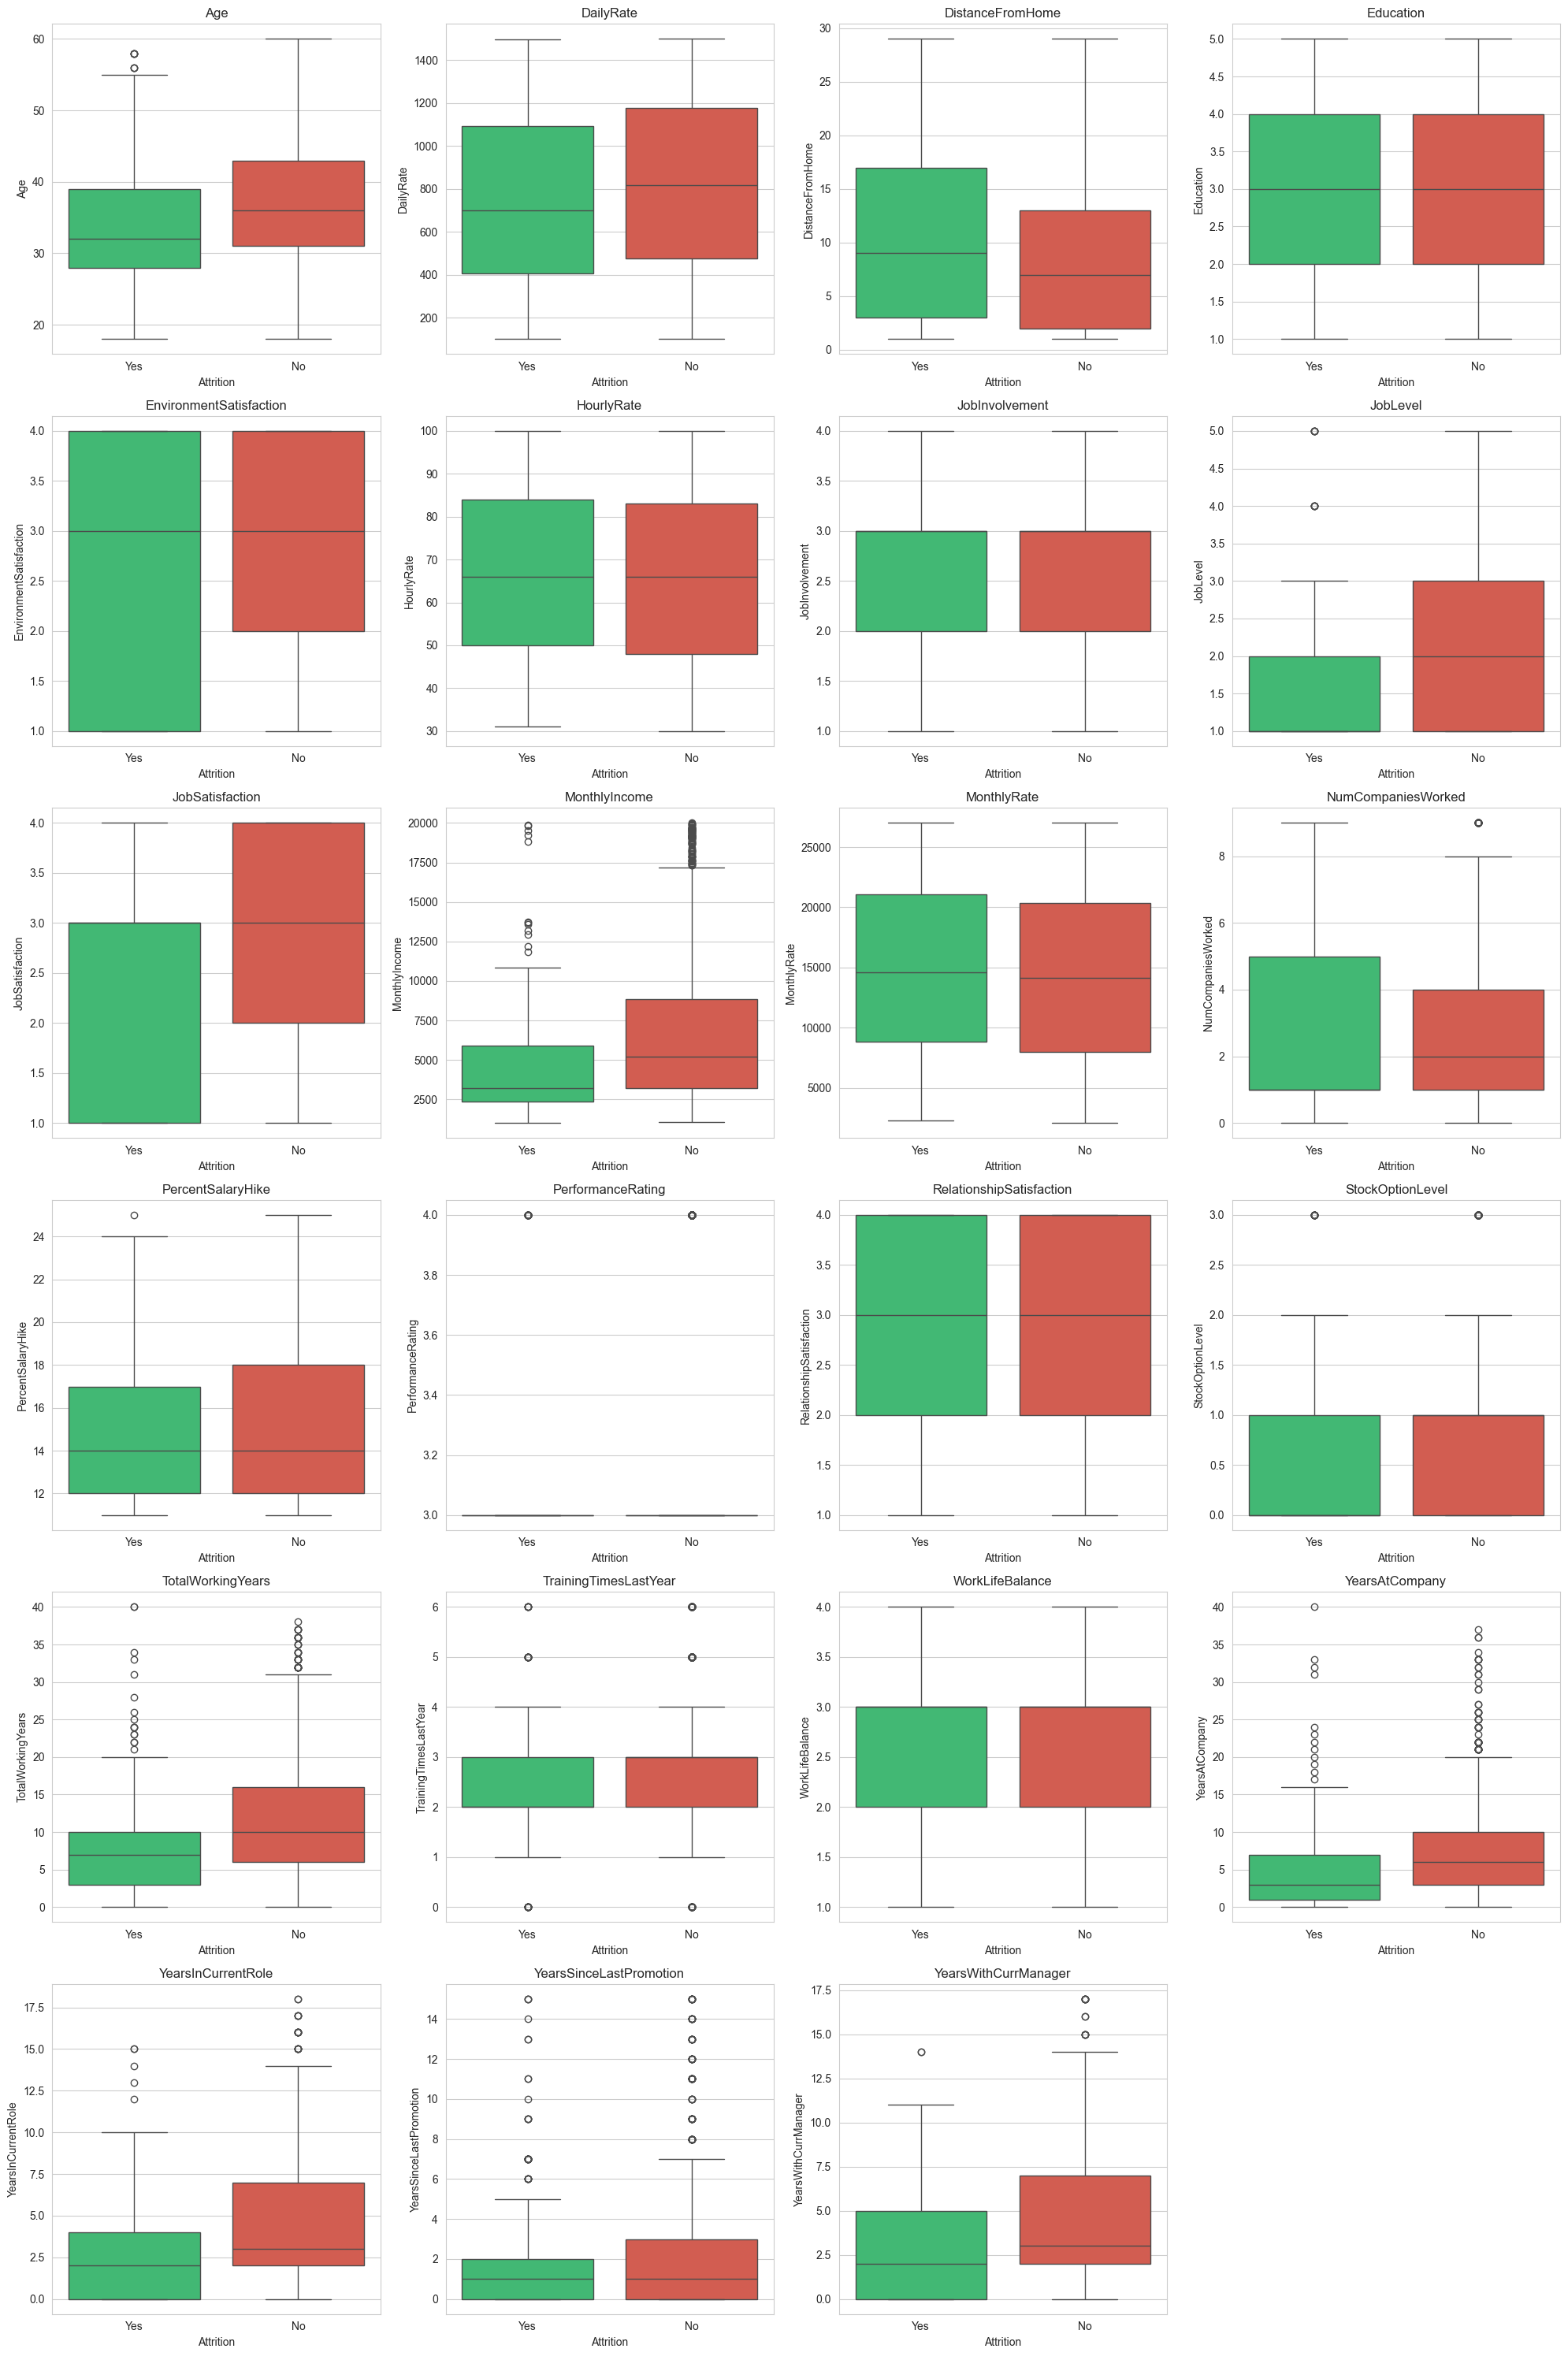

                 Feature  p_value Significant
                     Age  0.00000         Yes
                JobLevel  0.00000         Yes
          JobInvolvement  0.00000         Yes
           MonthlyIncome  0.00000         Yes
        StockOptionLevel  0.00000         Yes
    YearsWithCurrManager  0.00000         Yes
          YearsAtCompany  0.00000         Yes
       TotalWorkingYears  0.00000         Yes
      YearsInCurrentRole  0.00000         Yes
         JobSatisfaction  0.00008         Yes
 EnvironmentSatisfaction  0.00022         Yes
        DistanceFromHome  0.00239         Yes
               DailyRate  0.02900         Yes
 YearsSinceLastPromotion  0.04118         Yes
         WorkLifeBalance  0.04647         Yes
   TrainingTimesLastYear  0.04730         Yes
RelationshipSatisfaction  0.10203          No
      NumCompaniesWorked  0.24237          No
               Education  0.24483          No
       PercentSalaryHike  0.36551          No
             MonthlyRate  0.55875 

In [35]:
# Bivariate: Numerical vs Target (with statistical test)
import math

results = []

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df,
        x=TARGET_COL,
        y=col,
        ax=axes[i],
        hue=TARGET_COL,          # Avoids seaborn FutureWarning
        palette=["#2ecc71", "#e74c3c"],
        legend=False
    )
    axes[i].set_title(col)

    group_no = df[df[TARGET_COL] == "No"][col]
    group_yes = df[df[TARGET_COL] == "Yes"][col]

    stat, p_value = stats.mannwhitneyu(
        group_no,
        group_yes,
        alternative="two-sided"
    )

    results.append({
        "Feature": col,
        "p_value": round(p_value, 5),
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

# Remove empty subplots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/numerical_vs_target.png", dpi=150)
plt.show()

significance_df = pd.DataFrame(results).sort_values("p_value")
print(significance_df.to_string(index=False))

       Feature  p_value Significant
 MaritalStatus  0.00000         Yes
      OverTime  0.00000         Yes
       JobRole  0.00000         Yes
BusinessTravel  0.00001         Yes
    Department  0.00453         Yes
EducationField  0.00677         Yes
        Gender  0.29057          No


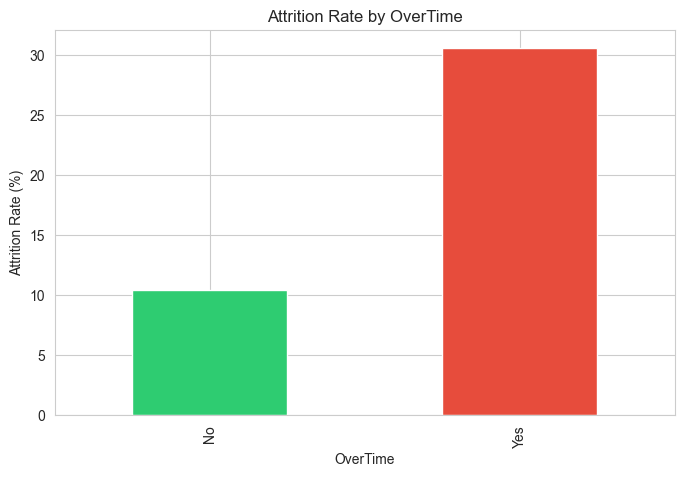

In [36]:
#  Bivariate: Categorical vs Target (Chi-Square Test)
chi_results = []
for col in cat_cols:
    contingency = pd.crosstab(df[col], df[TARGET_COL])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    chi_results.append({"Feature": col, "p_value": round(p, 5),
                         "Significant": "Yes" if p < 0.05 else "No"})

chi_df = pd.DataFrame(chi_results).sort_values("p_value")
print(chi_df.to_string(index=False))

# Attrition rate by OverTime (strongest predictor example)
fig, ax = plt.subplots(figsize=(8, 5))
attrition_rate = df.groupby("OverTime")[TARGET_COL].apply(lambda x: (x == "Yes").mean() * 100)
attrition_rate.plot(kind="bar", color=["#2ecc71", "#e74c3c"], ax=ax)
ax.set_ylabel("Attrition Rate (%)")
ax.set_title("Attrition Rate by OverTime")
plt.savefig(f"{FIGURES_DIR}/overtime_attrition_rate.png", dpi=150)
plt.show()

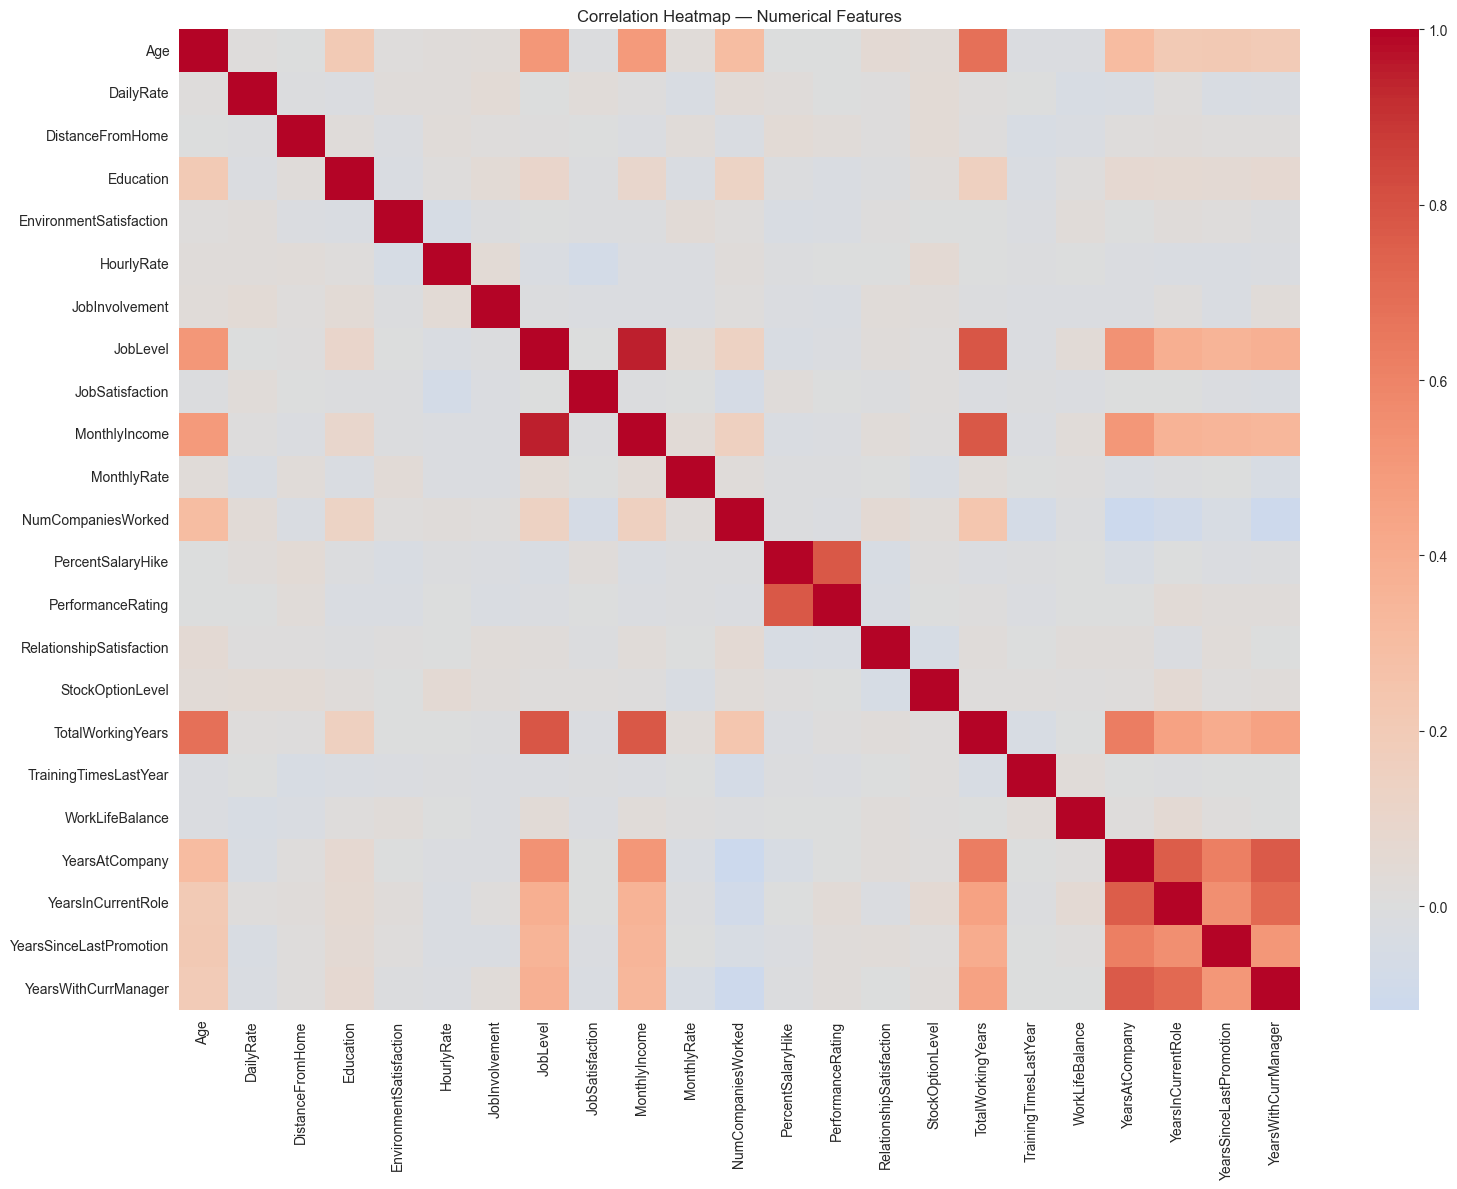

Highly correlated pairs (>0.6):
JobLevel              MonthlyIncome              0.950300
TotalWorkingYears     JobLevel                   0.782208
PercentSalaryHike     PerformanceRating          0.773550
MonthlyIncome         TotalWorkingYears          0.772893
YearsWithCurrManager  YearsAtCompany             0.769212
YearsAtCompany        YearsInCurrentRole         0.758754
YearsInCurrentRole    YearsWithCurrManager       0.714365
TotalWorkingYears     Age                        0.680381
YearsAtCompany        TotalWorkingYears          0.628133
                      YearsSinceLastPromotion    0.618409
dtype: float64


In [37]:
# Multivariate: Correlation Heatmap
plt.figure(figsize=(16, 12))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/correlation_heatmap.png", dpi=150)
plt.show()

# Find highly correlated pairs
high_corr = corr.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr < 1.0) & (high_corr > 0.6)]
print("Highly correlated pairs (>0.6):")
print(high_corr.drop_duplicates())

In [38]:
# Outlier Detection
outlier_summary = []
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({"Feature": col, "Outlier_Count": len(outliers)})

outlier_df = pd.DataFrame(outlier_summary).sort_values("Outlier_Count", ascending=False)
print(outlier_df.to_string(index=False))

                 Feature  Outlier_Count
   TrainingTimesLastYear            238
       PerformanceRating            226
           MonthlyIncome            114
 YearsSinceLastPromotion            107
          YearsAtCompany            104
        StockOptionLevel             85
       TotalWorkingYears             63
      NumCompaniesWorked             52
      YearsInCurrentRole             21
    YearsWithCurrManager             14
 EnvironmentSatisfaction              0
        DistanceFromHome              0
               DailyRate              0
                     Age              0
               Education              0
          JobInvolvement              0
              HourlyRate              0
RelationshipSatisfaction              0
             MonthlyRate              0
                JobLevel              0
       PercentSalaryHike              0
         JobSatisfaction              0
         WorkLifeBalance              0


In [39]:
# EDA Conclusions
print("=== EDA CONCLUSIONS ===")
print(f"1. Imbalance ratio: {ratio:.2f}:1 -> SMOTE + class_weight required")
print(f"2. Significant numerical features (p<0.05): {(significance_df['Significant']=='Yes').sum()}/{len(significance_df)}")
print(f"3. Significant categorical features (p<0.05): {(chi_df['Significant']=='Yes').sum()}/{len(chi_df)}")
print("4. Top correlated pairs flagged above for multicollinearity review")
print("5. Constants already dropped: EmployeeCount, StandardHours, Over18, EmployeeNumber")

=== EDA CONCLUSIONS ===
1. Imbalance ratio: 5.20:1 -> SMOTE + class_weight required
2. Significant numerical features (p<0.05): 16/23
3. Significant categorical features (p<0.05): 6/7
4. Top correlated pairs flagged above for multicollinearity review
5. Constants already dropped: EmployeeCount, StandardHours, Over18, EmployeeNumber


In [40]:
import sys
sys.path.append("../src")
from preprocessing import FeatureEngineer
from utils import PROCESSED_DATA_PATH

# Apply feature engineering (not encoding) to save an inspectable processed version
fe = FeatureEngineer()
df_processed = fe.transform(df)

df_processed.to_csv(PROCESSED_DATA_PATH, index=False)
print(f"Saved processed data to {PROCESSED_DATA_PATH}")
print(f"Shape: {df_processed.shape}")
df_processed.head()

Saved processed data to c:\Users\User\Desktop\employee-attrition-prediction\data\processed\cleaned_data.csv
Shape: (1470, 38)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PromotionStagnationIndex,IncomePerExperience,LoyaltyScore,CareerVelocity,SatisfactionComposite,OvertimeBurdenFlag,RoleStability
0,41,Yes,1,1102,Sales,1,2,Life Sciences,2,0,...,4,0,5,0.000000,665.888889,0.714286,0.222222,2.00,1,0.571429
1,49,No,2,279,Research & Development,8,1,Life Sciences,3,1,...,7,1,7,0.090909,466.363636,0.636364,0.181818,3.00,0,0.636364
2,37,Yes,1,1373,Research & Development,2,2,Other,4,1,...,0,0,0,0.000000,261.250000,0.000000,0.125000,3.00,0,0.000000
3,33,No,2,1392,Research & Development,3,4,Life Sciences,4,0,...,7,3,0,0.333333,323.222222,0.000000,0.111111,3.25,0,0.777778
4,27,No,1,591,Research & Development,2,1,Medical,1,1,...,2,2,2,0.666667,495.428571,0.666667,0.142857,2.50,0,0.666667
